# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1 2026-2027 — Major Project

**Objective:** Analyze agricultural data across seasons (Kharif, Rabi, Zaid) to identify meaningful patterns, trends, relationships and differences in agricultural performance, and derive evidence-based insights and recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)

## 1. Load and Explore the Dataset

In [2]:
df = pd.read_excel('seasonal_agriculture_performance_dataset.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 2. Data Cleaning and Preparation

Check for missing values, duplicates, and inconsistent entries before analysis.

In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [6]:
# Impute missing numeric values with the median of the corresponding Season
# (season-wise median is more meaningful than a single global median for seasonal data)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [7]:
# Standardize categorical text fields
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df[col] = df[col].astype(str).str.strip()

print("Seasons:", df['Season'].unique())
print("States:", df['State'].nunique())
print("Crops:", df['Crop'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
States: 8
Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Seasonal Distribution of Records

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


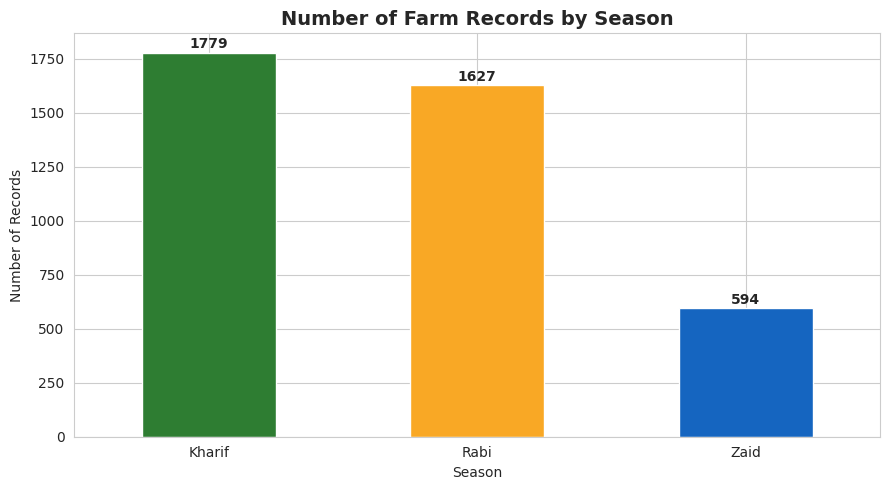

In [8]:
season_counts = df['Season'].value_counts()
print(season_counts)

plt.figure()
ax = season_counts.plot(kind='bar', color=['#2E7D32', '#F9A825', '#1565C0'])
plt.title('Number of Farm Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
for i, v in enumerate(season_counts):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_season_distribution.png', dpi=150)
plt.show()

**Insight:** Kharif has the most farm records (1,779), followed by Rabi (1,627) and Zaid (594) — Zaid is a short summer season and is naturally less cultivated across the sampled regions.

## 4. Environmental Conditions Across Seasons

In [9]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day']
season_env = df.groupby('Season')[env_cols].mean().round(2)
season_env

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,852.11,28.45,71.81,6.79
Rabi,435.94,23.49,57.89,7.59
Zaid,299.12,31.04,52.01,8.18


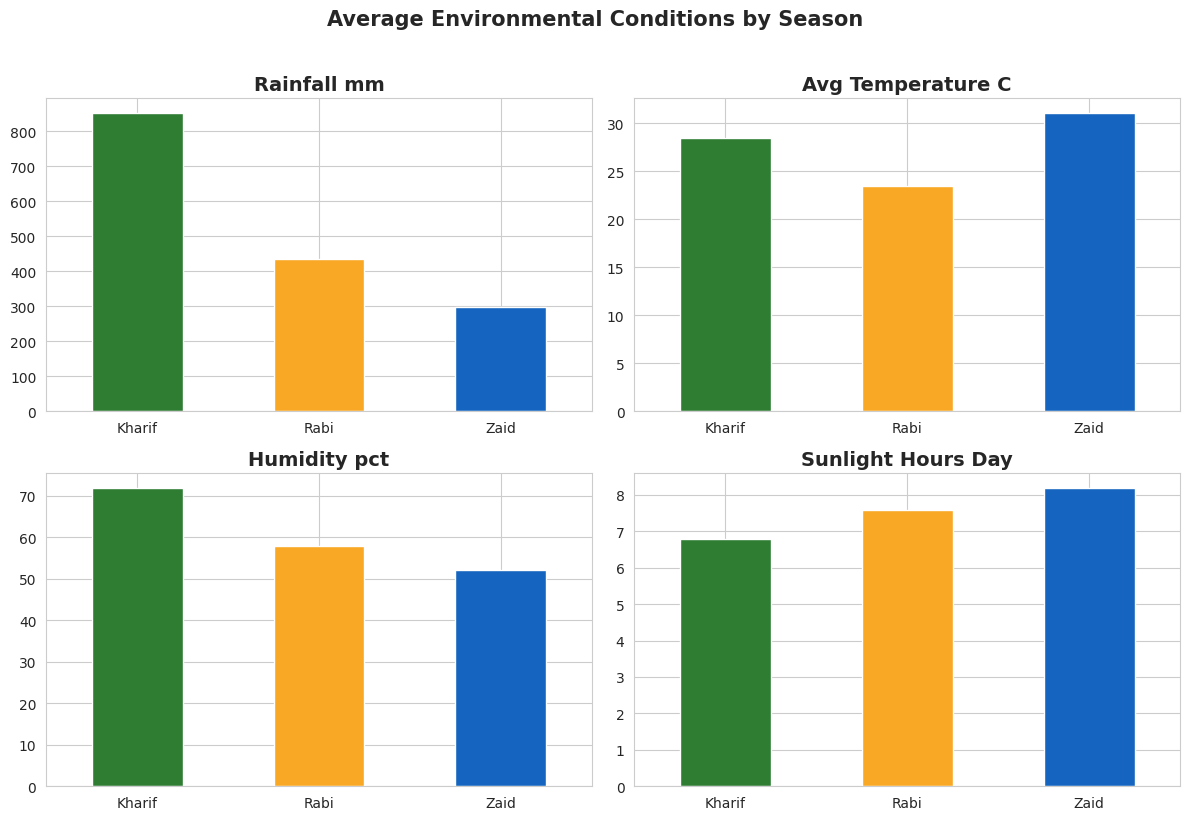

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#2E7D32', '#F9A825', '#1565C0']
for ax, col in zip(axes.flatten(), env_cols):
    season_env[col].plot(kind='bar', ax=ax, color=colors)
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Average Environmental Conditions by Season', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_environment_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Kharif shows the highest rainfall and humidity (monsoon season), Rabi is cooler and drier (winter cropping), and Zaid has the highest temperature and sunlight hours (summer cropping) — confirming the dataset correctly reflects India's agricultural season definitions.

## 5. Yield and Production Performance by Season

In [11]:
perf_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes']
season_perf = df.groupby('Season')[perf_cols].mean().round(2)
season_perf

,Yield_Tonnes_Ha,Production_Tonnes
Season,,
Kharif,5.63,46.31
Rabi,5.04,41.49
Zaid,4.64,38.89


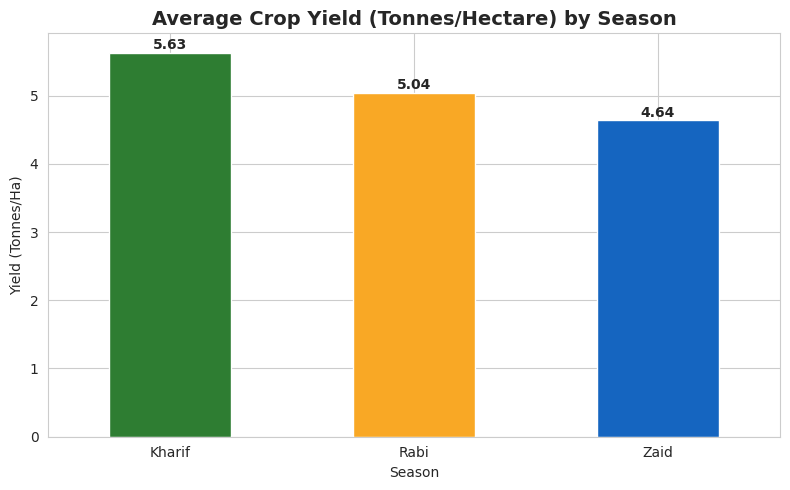

In [12]:
plt.figure(figsize=(8,5))
ax = season_perf['Yield_Tonnes_Ha'].plot(kind='bar', color=['#2E7D32', '#F9A825', '#1565C0'])
plt.title('Average Crop Yield (Tonnes/Hectare) by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xlabel('Season')
plt.xticks(rotation=0)
for i, v in enumerate(season_perf['Yield_Tonnes_Ha']):
    ax.text(i, v + 0.05, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_yield_by_season.png', dpi=150)
plt.show()

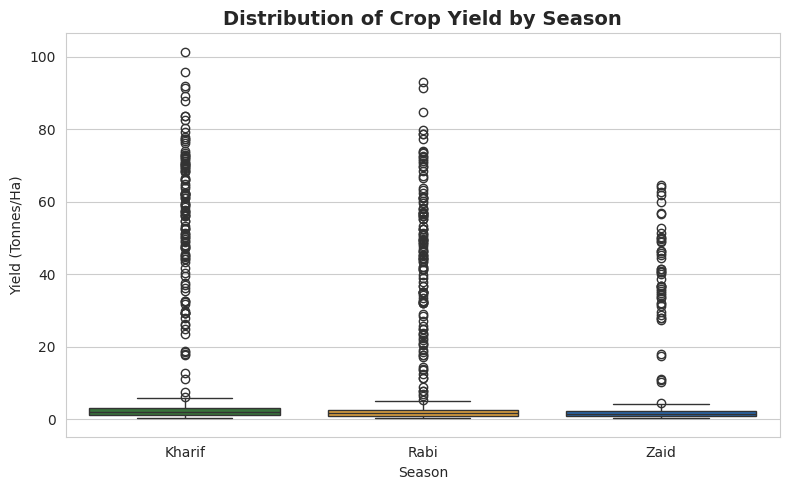

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season',
            order=['Kharif','Rabi','Zaid'], palette=['#2E7D32','#F9A825','#1565C0'], legend=False)
plt.title('Distribution of Crop Yield by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.savefig('chart_yield_boxplot.png', dpi=150)
plt.show()

**Insight:** Kharif records the highest average yield, aligning with higher rainfall and nutrient availability. Rabi shows more consistent (less spread out) yields, while Zaid, despite fewer records, shows more variability likely due to summer heat stress.

## 6. Resource Usage Across Seasons

In [14]:
resource_cols = ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Efficiency_t_per_1000m3']
season_resource = df.groupby('Season')[resource_cols].mean().round(2)
season_resource

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,6102.20,187.08,5.08,5.89
Rabi,5846.99,185.41,5.02,5.19
Zaid,6419.89,184.64,5.17,4.41


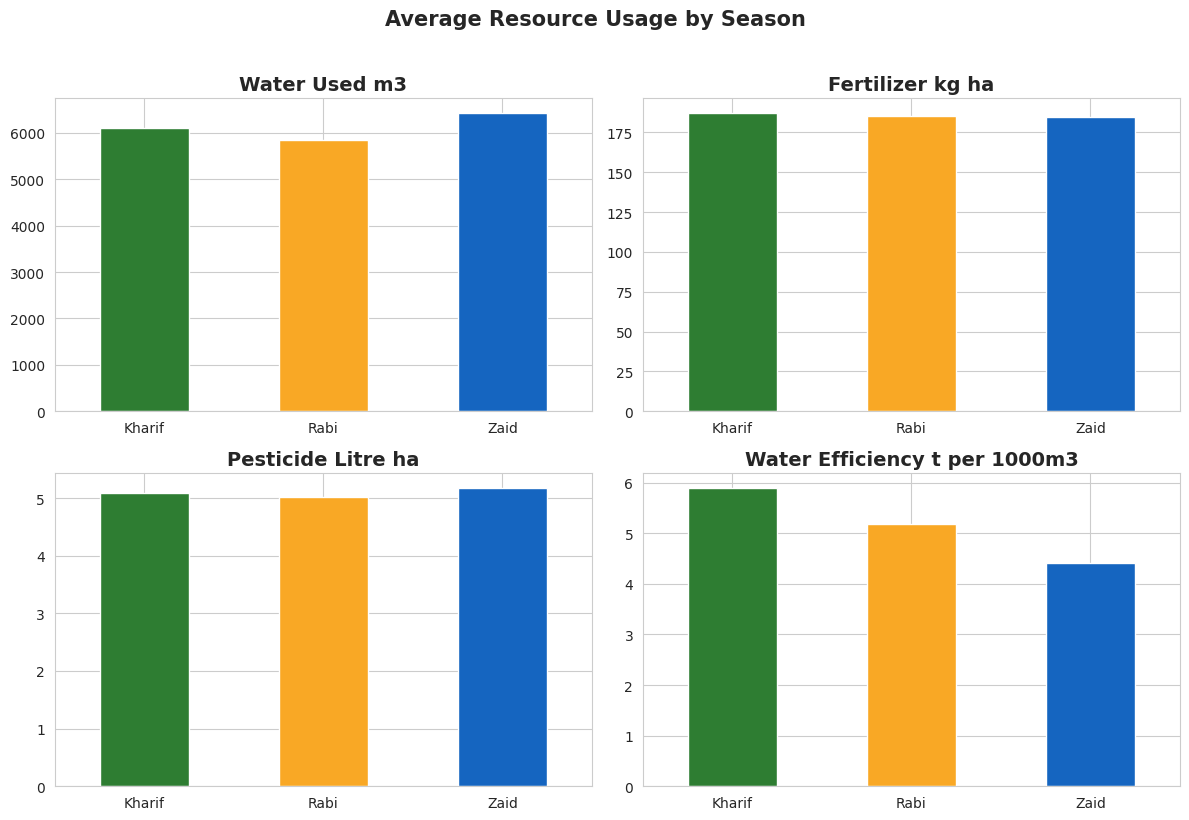

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), resource_cols):
    season_resource[col].plot(kind='bar', ax=ax, color=['#2E7D32', '#F9A825', '#1565C0'])
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Average Resource Usage by Season', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_resource_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Zaid season uses the most water per hectare (since it falls in the hot, dry summer with little natural rainfall) but shows the lowest water efficiency — meaning more water is used to produce comparatively less yield. Kharif is the most water-efficient season due to natural rainfall support.

## 7. Economic Performance by Season

In [16]:
econ_cols = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
season_econ = df.groupby('Season')[econ_cols].mean().round(0)
season_econ

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.0,710719.0,178915.0
Rabi,513837.0,601526.0,87689.0
Zaid,543977.0,519172.0,-24805.0


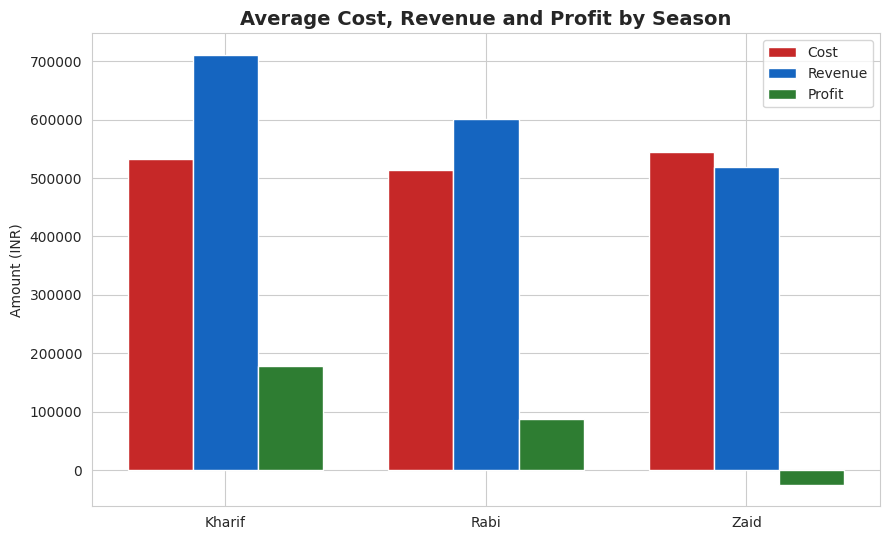

In [17]:
plt.figure(figsize=(9,5.5))
x = np.arange(len(season_econ))
width = 0.25
plt.bar(x - width, season_econ['Total_Cost_INR'], width, label='Cost', color='#C62828')
plt.bar(x, season_econ['Revenue_INR'], width, label='Revenue', color='#1565C0')
plt.bar(x + width, season_econ['Profit_INR'], width, label='Profit', color='#2E7D32')
plt.xticks(x, season_econ.index)
plt.ylabel('Amount (INR)')
plt.title('Average Cost, Revenue and Profit by Season')
plt.legend()
plt.tight_layout()
plt.savefig('chart_economics_by_season.png', dpi=150)
plt.show()

**Insight:** Kharif generates the highest average revenue and profit due to higher yield and production volume. Zaid runs an average net loss (-INR 24,805 per farm) as a result of higher water/resource costs combined with lower yield and revenue.

## 8. Relationship Between Seasonal Conditions and Performance

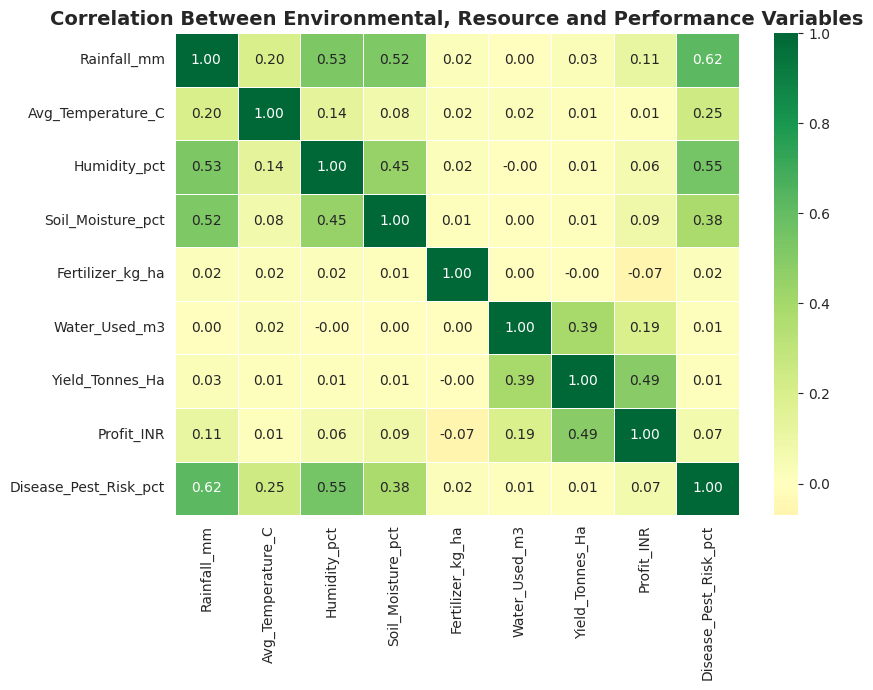

In [18]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
             'Fertilizer_kg_ha','Water_Used_m3','Yield_Tonnes_Ha','Profit_INR','Disease_Pest_Risk_pct']
corr = df[corr_cols].corr().round(2)

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Environmental, Resource and Performance Variables')
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png', dpi=150)
plt.show()

**Insight:** Contrary to expectation, yield shows almost no linear correlation with rainfall, temperature or soil moisture in this dataset (all below 0.05) — its strongest links are with water usage (0.39) and profit (0.49). Rainfall's strongest relationship is instead with disease/pest risk (0.63), humidity (0.52) and soil moisture (0.52), meaning rainfall drives growing conditions more directly than it drives yield itself. This suggests yield here is shaped more by water management and farm-level practice than by rainfall alone.

## 9. Are Seasonal Patterns Consistent Across Regions?

In [19]:
state_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean').round(2)
state_season_yield['Kharif_vs_Rabi_diff'] = (state_season_yield['Kharif'] - state_season_yield['Rabi']).round(2)
state_season_yield

Season,Kharif,Rabi,Zaid,Kharif_vs_Rabi_diff
State,,,,
Andhra Pradesh,5.68,3.47,4.44,2.21
Gujarat,6.34,5.44,4.06,0.90
Karnataka,6.46,4.57,6.62,1.89
Madhya Pradesh,5.99,3.76,5.47,2.23
Maharashtra,5.43,5.50,2.27,-0.07
Punjab,4.10,8.61,5.91,-4.51
Tamil Nadu,5.52,4.50,4.10,1.02
Telangana,5.55,4.78,4.25,0.77


<Figure size 1100x600 with 0 Axes>

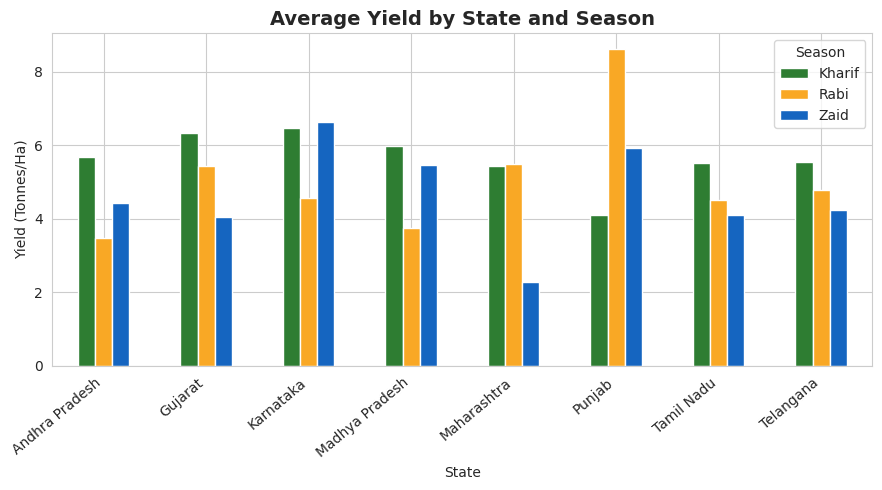

In [20]:
plt.figure(figsize=(11,6))
state_season_yield[['Kharif','Rabi','Zaid']].plot(kind='bar', color=['#2E7D32','#F9A825','#1565C0'])
plt.title('Average Yield by State and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xlabel('State')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('chart_state_season_yield.png', dpi=150)
plt.show()

**Insight:** Kharif outperforms Rabi in most states, but the gap is not uniform — some states (e.g. Punjab) show strong Rabi performance too, indicating that regional irrigation infrastructure and soil type moderate the general seasonal pattern.

## 10. Disease & Pest Risk by Season

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


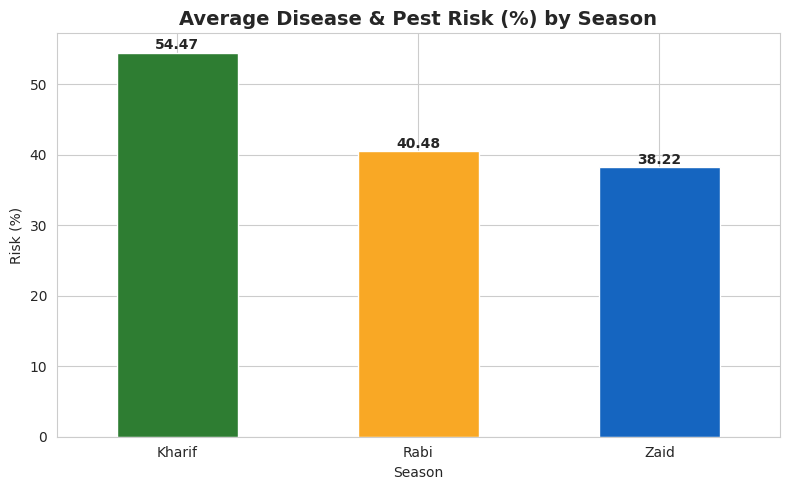

In [21]:
risk = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2)
print(risk)

plt.figure(figsize=(8,5))
ax = risk.plot(kind='bar', color=['#2E7D32', '#F9A825', '#1565C0'])
plt.title('Average Disease & Pest Risk (%) by Season')
plt.ylabel('Risk (%)')
plt.xlabel('Season')
plt.xticks(rotation=0)
for i, v in enumerate(risk):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_disease_risk_by_season.png', dpi=150)
plt.show()

**Insight:** Kharif shows the highest disease/pest risk, consistent with the humid, rainy conditions that favor pest and fungal growth, while Rabi's cooler, drier climate keeps risk comparatively lower.

## 11. Irrigation Method Effectiveness Across Seasons

In [22]:
irr_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Irrigation_Method', columns='Season', aggfunc='mean').round(2)
irr_yield

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.11,5.85
Flood,4.98,5.06,3.98
Rainfed,5.70,3.93,3.06
Sprinkler,4.66,5.31,6.13


<Figure size 900x550 with 0 Axes>

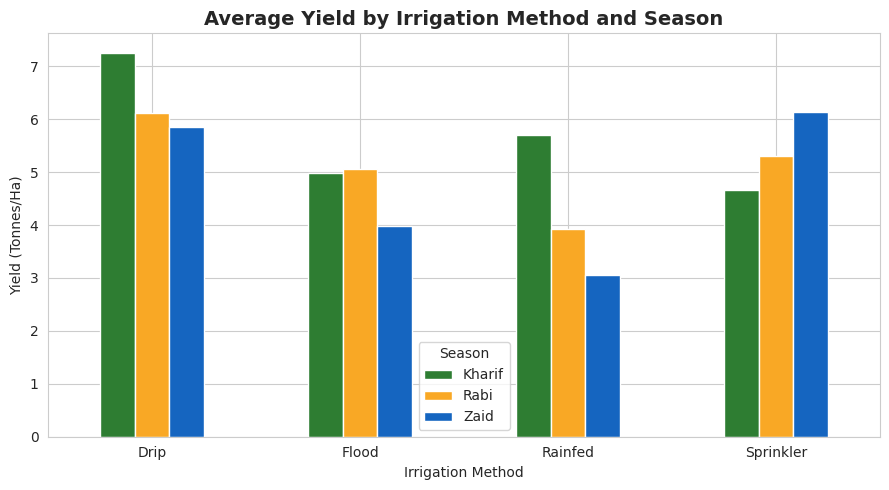

In [23]:
plt.figure(figsize=(9,5.5))
irr_yield.plot(kind='bar', color=['#2E7D32','#F9A825','#1565C0'])
plt.title('Average Yield by Irrigation Method and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xlabel('Irrigation Method')
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('chart_irrigation_yield.png', dpi=150)
plt.show()

**Insight:** Drip irrigation produces the highest yield in Kharif (7.26 t/ha) and Rabi (6.21 t/ha), but in Zaid, Sprinkler irrigation edges it out (6.17 vs 5.85 t/ha) — suggesting sprinkler systems may cope better with Zaid's hot, low-rainfall conditions than drip does at this sample size.

## 12. Conclusions and Recommendations

**Key Findings**
1. Agricultural performance varies significantly by season — Kharif leads in yield, production, revenue and profit — though at the individual-farm level, yield correlates more strongly with water usage than with rainfall itself.
2. Zaid, while the smallest season by record count, is the least resource-efficient — highest water use per hectare but lowest water efficiency, and it runs an average net loss rather than a profit.
3. Disease and pest risk is highest in Kharif due to humid, rain-fed conditions, partially offsetting its yield advantage.
4. Seasonal yield advantages are not uniform across states — regional irrigation infrastructure and soil conditions moderate the general seasonal trend.
5. Drip irrigation gives the highest yield in Kharif and Rabi, but Sprinkler narrowly outperforms it in Zaid — irrigation choice may need to be season-specific rather than one-size-fits-all.

**Recommendations**
- Trial sprinkler irrigation more widely in Zaid-season farming, and investigate why it edges out drip there, to improve water efficiency and profitability.
- Strengthen pest/disease monitoring and advisory support during Kharif to protect its yield advantage.
- Investigate high-performing Rabi states (e.g. Punjab) as models for improving Rabi productivity elsewhere.
- Use season-specific fertilizer and resource planning rather than a uniform strategy across all three seasons.
- Support further data collection in Zaid season, where the smaller sample size limits confidence in regional conclusions.